## WEEK 3 - NLP Foundations + Sequence Models

In [113]:
# 06-03-2026
# Stemming

In [ ]:
! pip install nltk

In [1]:
import nltk
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize,  sent_tokenize

In [2]:
words = "Raha is enjoying! at her ;ne^arest river,  bank addition? with 'winners'. Bank in venezuela"

In [4]:
print((sent_tokenize(words)))
print(word_tokenize(words))

['Raha is enjoying!', 'at her ;ne^arest river,  bank addition?', "with 'winners'.", 'Bank in venezuela']
['Raha', 'is', 'enjoying', '!', 'at', 'her', ';', 'ne^arest', 'river', ',', 'bank', 'addition', '?', 'with', "'winners", "'", '.', 'Bank', 'in', 'venezuela']


In [5]:
from nltk import pos_tag
# Part-of-speech (POS) tagging is the NLP process of labeling words
# within a text with their corresponding grammatical roles—such as 
# nouns, verbs, adjectives, and adverbs—based on context.

In [6]:
stemmer = PorterStemmer()

In [7]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/shrutik/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [8]:
# word = "Raha is enjoying at her nearest river  bank addition with winners Bank in venezuela"
word = "automatics"

token_w = word_tokenize(word)
word_s = [stemmer.stem(i) for i in token_w]

print(token_w)
print(word_s)

['automatics']
['automat']


In [9]:
# Lemmantization

In [10]:
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to /home/shrutik/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [11]:
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /home/shrutik/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [12]:
pos_w = pos_tag(token_w)

In [13]:
pos_w

[('automatics', 'NNS')]

In [14]:
import nltk
from nltk.stem import WordNetLemmatizer as wnl

lemmatizer = wnl()
print([lemmatizer.lemmatize(i,pos='v') for i,tag in pos_w])

['automatics']


In [15]:
pos_w

[('automatics', 'NNS')]

In [16]:
# Stopwords

In [17]:
from nltk.corpus import stopwords

In [18]:
import nltk

nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/shrutik/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [19]:
def stop_w(text):
    return ",".join([word for word in text.lower().split() if word not in stopwords.words('english')])

text = "you are very lucky Because also you have such a nice friend IS very good and also it have some nice shoes"
new = stop_w(text)
new

'lucky,also,nice,friend,good,also,nice,shoes'

In [20]:
[i**2 if i%2==0 else i for i in range(1,10)]

[1, 4, 3, 16, 5, 36, 7, 64, 9]

In [21]:
text = "hi hello how are you"
(",").join(text.split())

'hi,hello,how,are,you'

In [22]:
text = "You are very lucky because your friend is very good and also it has some nice shoes"
len(text)

83

In [135]:
# Regular Expression

In [16]:
import re

In [37]:
rm = re.compile(r'[a-zA-Z0-9\s]')
# vm = re.compile('[^a-zA-Z0-9]')

In [38]:
nn = "A man, a plan, a canal, Panama"
p = "Data                       !@ Science#Roc      ks123"

In [39]:
new = rm.sub('',p)

In [40]:
new

'!@#'

In [ ]:
import sys
!{sys.executable} -m pip install pandas

In [ ]:
import sys
!{sys.executable} -m pip install kagglehub

In [143]:
import kagglehub


path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")

print("Path to dataset files:", path)

Path to dataset files: /home/shrutik/.cache/kagglehub/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/versions/1


In [144]:
# /home/shrutik/.cache/kagglehub/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/versions/1

In [ ]:
import pandas as pd
import os

file_path = os.path.join("//shrutik/.cache/kagglehub/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/versions/1", "IMDB Dataset.csv")
data = pd.read_csv(file_path)

In [ ]:
# Lowercasing

In [ ]:
data['review'] = data['review'].str.lower()

In [ ]:
# 09-03-26

In [ ]:
# remove HTML tags

In [ ]:
def remove_htags(text):
    pattern = re.compile(r'[<@!?/.>]')
    return pattern.sub('',text)


In [ ]:
data['review'] = data['review'].apply(remove_htags)

In [ ]:
# remove URLs

In [ ]:
def rmurl(text):
    # patt = re.compile(r'www/./s+,https?,://,.com,.in')
    patt = re.compile(r'https?://\S+|www\.\S+')
    return patt.sub("",text)

In [ ]:
data['review'] = data['review'].apply(rmurl)

In [ ]:
# remove punctuation

In [ ]:
def rmpunct(text):
    pt = re.compile('[!"#$%&\'()*+,-/:;<=>?@[\\]^_`{|}~]')
    # pt = re.compile('[^\w\d\s]')
    text = pt.sub("",text)
    return " ".join(text.split())

In [ ]:
data['review'] = data['review'].apply(rmpunct)

In [ ]:
# Tokenization Techniques

In [ ]:
# 1. Character Tokenization

In [ ]:
tk = list(words)
print(tk)

In [ ]:
nn = {ch:i for i,ch in enumerate(sorted(set(tk)))}
print(nn)

In [ ]:
bb = [nn[i] for i in tk]
print(bb)

In [ ]:
import torch
import torch.nn.functional as F
input_ids = torch.tensor(bb)
one_hot_encodings = F.one_hot(input_ids, num_classes=len(nn))
one_hot_encodings.shape

In [ ]:
print(f"Token: {tk[10]}")
print(f"Tensor index: {input_ids[10]}")
print(f"One-hot: {one_hot_encodings[10]}")

In [ ]:
# 2. Word Tokenization

In [ ]:
# using split - can't split punctuation and special character

In [ ]:
print(words.split())

In [ ]:
# using nltk - can split punctuation and special character

In [ ]:
new = word_tokenize(words)
print(new)

In [ ]:
# 3. Subword Tokenization

In [ ]:
!pip install transformers

In [ ]:
import sys
!{sys.executable} -m pip install transformers

In [ ]:
from transformers import AutoTokenizer
model_ckpt = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

In [ ]:
encoded_text = tokenizer(words )

In [ ]:
tokens = tokenizer.convert_ids_to_tokens(encoded_text.input_ids)
print(tokens)

In [ ]:
print(tokenizer.convert_tokens_to_string(tokens))

In [ ]:
tokenizer.vocab_size

In [ ]:
tokenizer.model_max_length

In [ ]:
# 10-03-26

In [ ]:
# Implementing Word2Vec 

In [ ]:
import sys
!{sys.executable} -m pip install gensim

In [1]:
from nltk.tokenize import word_tokenize

In [8]:
words = [
    "i am learning Machine learning concept",
    "you have nice car    red",
    "this house is very expensive.",
    "This scene is very beautiful",
    "you are very lucky",
    
]

In [9]:
token_words = [word_tokenize(i.lower()) for i in words]

In [10]:
token_words

[['i', 'am', 'learning', 'machine', 'learning', 'concept'],
 ['you', 'have', 'nice', 'car', 'red'],
 ['this', 'house', 'is', 'very', 'expensive', '.'],
 ['this', 'scene', 'is', 'very', 'beautiful'],
 ['you', 'are', 'very', 'lucky']]

In [11]:
from gensim.models import Word2Vec

In [ ]:
model = Word2Vec(
    token_words,
    vector_size=100  #embedding dimension
    window=5,          # context window
    min_count=1,
    workers=4,
    sg = 1
)


In [19]:
vector = model.wv["very"]

In [20]:
vector

array([-0.00594483,  0.00261721,  0.05670388,  0.10009529, -0.10338183,
       -0.07906749,  0.07175083,  0.09969281, -0.05572703], dtype=float32)

In [16]:
model.wv.most_similar("beautiful")

[('i', 0.31900981068611145),
 ('concept', 0.1747603863477707),
 ('machine', 0.11928386986255646),
 ('house', 0.11120022088289261),
 ('expensive', 0.1088901236653328),
 ('nice', 0.10560768097639084),
 ('very', 0.09291310608386993),
 ('have', 0.08059286326169968),
 ('am', 0.07913301885128021),
 ('are', 0.004844647832214832)]

In [ ]:
# Sentiment Analysis - TF-IDF

In [ ]:
import pandas as pd

data = {
    "text": [
        "I absolutely loved this movie, it was fantastic",
        "The film was boring and too long",
        "Amazing acting and a beautiful story",
        "I did not like the plot at all",
        "The cinematography was stunning",
        "This was the worst movie I have ever seen",
        "Brilliant direction and great music",
        "The characters were dull and uninteresting",
        "What a wonderful and emotional film",
        "The story made no sense",
        "An outstanding performance by the lead actor",
        "I regret wasting my time watching this",
        "The movie was enjoyable and fun to watch",
        "Terrible screenplay and poor acting",
        "A masterpiece with incredible visuals",

        "I really enjoyed every moment of this movie",
        "The movie was disappointing and poorly written",
        "Fantastic storytelling and great characters",
        "The acting was horrible and very fake",
        "I loved the soundtrack and the visuals",
        "The film felt slow and extremely boring",
        "This movie made me very happy",
        "The plot was confusing and messy",
        "Absolutely brilliant movie experience",
        "I would never watch this movie again",
        "The direction was excellent",
        "The film was a complete waste of time",
        "Such a touching and inspiring story",
        "The acting ruined the entire movie",
        "I highly recommend this film",
        "The movie was poorly directed",
        "A very entertaining and fun film",
        "I did not enjoy the movie at all",
        "The story was powerful and engaging",
        "The characters were badly written",
        "One of the best movies I have seen",
        "The film was extremely dull",
        "Wonderful cinematography and acting",
        "The movie was frustrating and boring",
        "A truly beautiful and emotional film"
    ],

    "sentiment": [
        "positive","negative","positive","negative","positive",
        "negative","positive","negative","positive","negative",
        "positive","negative","positive","negative","positive",

        "positive","negative","positive","negative","positive",
        "negative","positive","negative","positive","negative",
        "positive","negative","positive","negative","positive",
        "negative","positive","negative","positive","negative",
        "positive","negative","positive","negative","positive"
    ]
}


more_text = [
    "I really loved the acting in this film",
    "The movie was extremely boring",
    "An incredible cinematic experience",
    "The plot was weak and predictable",
    "Beautiful visuals and great direction",
    "I did not enjoy the story",
    "The performances were outstanding",
    "This movie felt very slow",
    "A fantastic and entertaining film",
    "The dialogue was poorly written",
    "Such a heartwarming movie",
    "I almost fell asleep watching it",
    "Brilliant acting and storytelling",
    "The movie had terrible pacing",
    "Absolutely loved the characters",
    "The film was confusing and dull",
    "A very inspiring movie",
    "The screenplay was awful",
    "I had a great time watching this",
    "The movie was painful to watch",
    "A truly amazing film",
    "The direction was very bad",
    "Wonderful acting performances",
    "The story was extremely boring",
    "One of the most enjoyable films",
    "I regret watching this movie",
    "A powerful and emotional story",
    "The film lacked originality",
    "Fantastic visuals and music",
    "The acting was very disappointing",
    "A delightful movie experience",
    "The movie was not interesting",
    "I loved the cinematography",
    "The plot was poorly executed",
    "Great performances by the cast",
    "The movie felt pointless",
    "Such a lovely and emotional film",
    "The story dragged too much",
    "A highly entertaining movie",
    "The film was very frustrating",
    "I really liked this movie",
    "The characters were boring",
    "An unforgettable film experience",
    "The movie had terrible acting",
    "A charming and beautiful story",
    "The film was very disappointing",
    "A wonderful and touching film",
    "The plot was extremely weak",
    "One of the best films this year",
    "The movie felt very cheap",
    "Fantastic acting and direction",
    "The film was not worth watching",
    "I really enjoyed the storyline",
    "The movie was dull and slow",
    "A brilliant cinematic masterpiece",
    "The acting ruined the film",
    "A very satisfying movie",
    "The film was badly made",
    "A joyful and entertaining movie",
    "The movie was extremely disappointing"
]

more_sentiment = [
    "positive","negative","positive","negative","positive","negative",
    "positive","negative","positive","negative","positive","negative",
    "positive","negative","positive","negative","positive","negative",
    "positive","negative","positive","negative","positive","negative",
    "positive","negative","positive","negative","positive","negative",
    "positive","negative","positive","negative","positive","negative",
    "positive","negative","positive","negative","positive","negative",
    "positive","negative","positive","negative","positive","negative",
    "positive","negative","positive","negative","positive","negative",
    "positive","negative","positive","negative","positive","negative"
]

# Append to your existing dataset
data["text"].extend(more_text)
data["sentiment"].extend(more_sentiment)

df = pd.DataFrame(data)

print("Total rows:", len(df))
df.head()

In [ ]:
# Exercise: 1
# Sentiment classifier (TF-IDF + LogisticRegression)

In [45]:
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score,classification_report,f1_score,recall_score

In [46]:
# vect = TfidfVectorizer()
vect = TfidfVectorizer(
    max_features=20000,
    min_df=5,
    max_df=0.9,
    ngram_range=(1,2),
    stop_words="english",
    sublinear_tf=True
)

model = LogisticRegression( C=1,
                            max_iter=1000,
                            solver="liblinear"
                          )

In [47]:
df.head(2)

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive


In [48]:
X = vect.fit_transform(df["review"])

In [50]:
le = LabelEncoder()

In [51]:
df['sentiment'] = le.fit_transform(df['sentiment'])

In [52]:
y = df["sentiment"]

In [53]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [54]:
model.fit(X_train,
          y_train,
         )

LogisticRegression(C=1, max_iter=1000, solver='liblinear')

In [55]:
y_pred = model.predict(X_test)

In [56]:
y_pred
# 0: Negative
# 1: Positive

array([0, 1, 0, ..., 1, 0, 1])

In [57]:
ac = accuracy_score(y_pred,y_test)

In [58]:
print(f"Accuracy Score:{ac}")

Accuracy Score:0.8999


In [59]:
X_test.shape

(10000, 20000)

In [60]:
print(f"Classification report:\n{classification_report(y_test,y_pred)}")

Classification report:
              precision    recall  f1-score   support

           0       0.91      0.89      0.90      4961
           1       0.89      0.91      0.90      5039

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



In [67]:
def check_logreg(text):
    text_v = vect.transform([text])
    pred = model.predict(text_v)
    return "Positive" if pred >= 0.5 else "Negative"

In [103]:
check_logreg("meera is a girl")

'Negative'

In [347]:
from sklearn.metrics import mean_squared_error, r2_score

# predictions
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

# errors
train_mse = mean_squared_error(y_train, train_pred)
test_mse = mean_squared_error(y_test, test_pred)

print("Train MSE:", train_mse)
print("Test MSE:", test_mse)

Train MSE: 0.066
Test MSE: 0.1001


In [348]:
print("Train R2:", r2_score(y_train, train_pred))
print("Test R2:", r2_score(y_test, test_pred))

Train R2: 0.7359989961361828
Test R2: 0.5995756381818271


In [349]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5, scoring="neg_mean_squared_error")

print(scores.mean())

-0.10203999999999999


In [ ]:
print(f"{f1_score(y_test,y_pred)}")

In [ ]:
print(f"{recall_score(y_test,y_pred)}")

In [ ]:
!{sys.executable} -m pip install seaborn

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [ ]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_pred)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [ ]:
# Unseen data

In [477]:
nn = ["you have not good eye"]

In [478]:
n1 = vect.transform(nn)

In [479]:
nnn = model.predict(n1).item()
nnn

1

In [ ]:
# 11-03-26
# LSTM

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
import numpy as np


- input
- model
- model compile(opt,loss)
- model fit
- model summary

In [ ]:
X = np.array([
    [1,2,3],
    [4,5,6],
    [7,8,9]
    ])
y = np.array([4,5,6])

In [ ]:
model = Sequential([
    Embedding(input_dim=10,output_dim=8,input_length=3),
    LSTM(16),
    Dense(1,activation ="linear")
])

In [ ]:
model.compile(optimizer="adam",loss="mse")

In [ ]:
model.fit(X,y,epochs=10)

In [ ]:
model.summary()

In [ ]:
# model.predict([[4,5,6]])
n = model.predict(np.array([[1,2,3]]))

In [ ]:
n

In [ ]:
# import numpy as np
# import tensorflow as tf
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import LSTM, Dense

# X = np.array([
#     [1,2,3],
#     [2,3,4],
#     [3,4,5],
#     [4,5,6]
# ])

# y = np.array([4,5,6,7])

# model = Sequential([
#     LSTM(32, input_shape=(3,1)),
#     Dense(1)
# ])

# X = X.reshape((4,3,1))

# model.compile(optimizer="adam", loss="mse")

# model.fit(X,y,epochs=1000,verbose=0)

# print(model.predict(np.array([[3,2,1]]).reshape(1,3,1)))


In [ ]:
df

In [ ]:

sentence = ["The movie was absolutely wonderful"]

seq = tokenizer.texts_to_sequences(sentence)
pad = pad_sequences(seq, maxlen=max_len, padding="post")

pred = model.predict(pad)

print("Prediction probability:", pred)

In [147]:
data = df.copy()

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

# -------------------------------
# 1 Create dataframe
# -------------------------------

df = pd.DataFrame(data)

print("Total rows:", len(df))
print(df.head())

# -------------------------------
# 2 Encode labels
# -------------------------------

le = LabelEncoder()
df["sentiment"] = le.fit_transform(df["sentiment"])

X = df["text"]
y = df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

vocab_size = 10000

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

# -------------------------------
# 5 Convert text → sequences
# -------------------------------

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# -------------------------------
# 6 Padding
# -------------------------------

max_len = 20

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding="post")   # adds zeros at end so every sequence has the same length.
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding="post")

# 7 Build LSTM model
# -------------------------------

model = Sequential([
    
    Embedding(input_dim=5000, output_dim=64),

    LSTM(64),

    Dense(32, activation="relu"),

    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# -------------------------------
# 8 Train model
# -------------------------------

history = model.fit(
    X_train_pad,
    y_train,
    epochs=20,
    batch_size=8,
    validation_split = 0.2
)

# -------------------------------
# 9 Evaluate model
# -------------------------------

loss, acc = model.evaluate(X_test_pad, y_test)

print("Test Accuracy:", acc)

def predict_sentiment(text):

    seq = tokenizer.texts_to_sequences([text])
    pad = pad_sequences(seq, maxlen=max_len, padding="pre")

    pred = model.predict(pad)

    if pred > 0.5:
        return "positive"
    else:
        return "negative"

predict_sentiment("today's wheather is not good")

In [ ]:
# 12-03-26

In [158]:
# Exercise:2
# LSTM Classifier

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

2026-03-25 10:58:05.784484: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
df = pd.read_csv("/home/shrutik/movie.csv")

In [3]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
# encode labels
le = LabelEncoder()
df['sentiment'] = le.fit_transform(df['sentiment'])

In [5]:
# define X,y
X = df['review']
y = df['sentiment']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [6]:
# tokenize words
vocab_size = 10000
tokenizer = Tokenizer(num_words= vocab_size,oov_token="<oov>")
tokenizer.fit_on_texts(X_train)

In [8]:
X_train


39087    That's what I kept asking myself during the ma...
30893    I did not watch the entire movie. I could not ...
45278    A touching love story reminiscent of In the M...
16398    This latter-day Fulci schlocker is a totally a...
13653    First of all, I firmly believe that Norwegian ...
                               ...                        
11284    `Shadow Magic' recaptures the joy and amazemen...
44732    I found this movie to be quite enjoyable and f...
38158    Avoid this one! It is a terrible movie. So wha...
860      This production was quite a surprise for me. I...
15795    This is a decent movie. Although little bit sh...
Name: review, Length: 40000, dtype: object

In [9]:
# text -> sequence
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [13]:
# padding
max_len = 150
X_train_pad = pad_sequences(X_train_seq,
                           maxlen=max_len,
                           padding = 'post')
X_test_pad = pad_sequences(X_test_seq,
                           maxlen=max_len,
                           padding = 'post')

In [14]:
# build model
model_lc = Sequential([
    Embedding(input_dim=10000,output_dim=32),

    LSTM(32,dropout=0.2,recurrent_dropout=0.2),

    Dense(32,activation='relu',kernel_regularizer=tf.keras.regularizers.l2(0.01)),
    Dropout(0.5),
    Dense(1,activation='sigmoid')
])

In [15]:
# compile model
model_lc.compile(
    optimizer='adam',
    loss = 'binary_crossentropy',
    metrics=['accuracy']
)

In [16]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

In [17]:
# train model
history = model_lc.fit(X_train_pad,
                   y_train,
                   epochs=5,
                   batch_size=32,
                   validation_split=0.2,
                   callbacks =[early_stop]
                   )

Epoch 1/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 52s 49ms/step - accuracy: 0.6372 - loss: 0.6784 - val_accuracy: 0.6952 - val_loss: 0.5939
Epoch 2/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 78s 45ms/step - accuracy: 0.7181 - loss: 0.5635 - val_accuracy: 0.8240 - val_loss: 0.4390
Epoch 3/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 42s 42ms/step - accuracy: 0.7673 - loss: 0.5025 - val_accuracy: 0.8256 - val_loss: 0.4214
Epoch 4/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 46s 46ms/step - accuracy: 0.8461 - loss: 0.4079 - val_accuracy: 0.8396 - val_loss: 0.3957
Epoch 5/5
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 41s 41ms/step - accuracy: 0.8637 - loss: 0.3616 - val_accuracy: 0.8447 - val_loss: 0.3686


In [88]:
y_pred_lc = model_lc.predict(X_test_pad)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


In [111]:
y_pred_lc = [1 if i >= 0.5 else 0 for i in y_pred_lc]

In [90]:
X_train.head()

39087    That's what I kept asking myself during the ma...
30893    I did not watch the entire movie. I could not ...
45278    A touching love story reminiscent of In the M...
16398    This latter-day Fulci schlocker is a totally a...
13653    First of all, I firmly believe that Norwegian ...
Name: review, dtype: object

In [91]:
from sklearn.metrics import mean_squared_error, r2_score

# predictions
train_pred = model_lc.predict(X_train_pad)
test_pred = model_lc.predict(X_test_pad)

# errors
train_mse = mean_squared_error(y_train, train_pred)
test_mse = mean_squared_error(y_test, test_pred)

print("Train MSE:", train_mse)
print("Test MSE:", test_mse)
print(f"train_test difference {round(test_mse - train_mse,4)}")

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step
Train MSE: 0.09453726288012347
Test MSE: 0.11548165142546049
train_test difference 0.0209


In [151]:
model_lc.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (32, 150, 32)          │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (32, 32)               │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (32, 32)               │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (32, 32)               │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (32, 1)                │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 329,409 (1.26 MB)

 Trainable params: 329,409 (1.26 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
loss,acc = model_lc.evaluate(X_test_pad,y_test)
print(f"loss;{loss} and accuracy:{acc}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8544 - loss: 0.3751
loss;0.37513887882232666 and accuracy:0.8543999791145325


In [11]:
def check_sentiments(text):

    text_sq = tokenizer.texts_to_sequences([text])

    text_pd = pad_sequences(text_sq,
                           maxlen=max_len,
                           padding='post')
    pred = model_lc.predict(text_pd).item()

    return "Positive" if pred >= 0.5 else "Negative"

In [12]:
check_sentiments("water is not  so tasty")

NameError: name 'max_len' is not defined

In [ ]:
# Compare Performance (LSTM VS LogReg)

In [105]:
from sklearn.metrics import precision_score

In [108]:
y_pred_lc

array([[0.64501077],
       [0.87944376],
       [0.0963291 ],
       ...,
       [0.9100969 ],
       [0.07515093],
       [0.9468081 ]], dtype=float32)

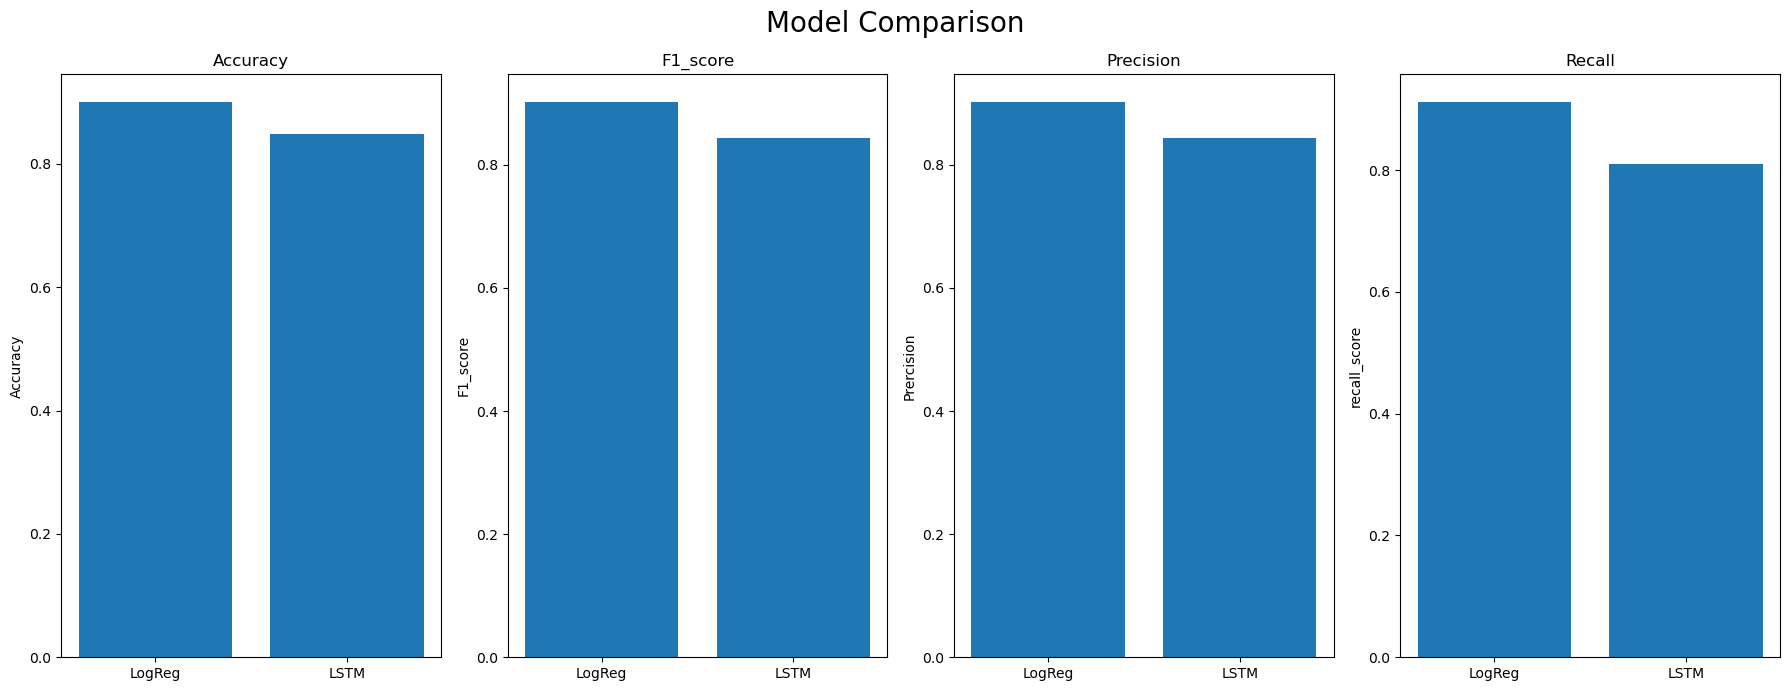

In [113]:
import matplotlib.pyplot as plt

models = ["LogReg", "LSTM"]

# --------------------------------------

scores_ac = [
    accuracy_score(y_test, y_pred),
    accuracy_score(y_test, y_pred_lc)
]

plt.figure(figsize=(18,7))

plt.subplot(1,4,1)
plt.bar(models, scores_ac)
plt.ylabel("Accuracy")
plt.title("Accuracy")

# --------------------------------------

scores_f1 = [
    f1_score(y_test, y_pred),
    f1_score(y_test, y_pred_lc)
]

plt.subplot(1,4,2)
plt.bar(models, scores_f1)
plt.ylabel("F1_score")
plt.title("F1_score")

# --------------------------------------

scores_pr = [
    precision_score(y_test, y_pred),
    precision_score(y_test, y_pred_lc)
]

plt.subplot(1,4,3)
plt.bar(models, scores_f1)
plt.ylabel("Prercision")
plt.title("Precision")


# --------------------------------------

scores_rs = [
    recall_score(y_test, y_pred),
    recall_score(y_test, y_pred_lc)
]

plt.subplot(1,4,4)
plt.bar(models, scores_rs)
plt.ylabel("recall_score")
plt.title("Recall")

# --------------------------------------

plt.suptitle("Model Comparison",fontsize=20)
plt.tight_layout()
plt.show()

In [130]:
def swindow(arr,k):
    if len(arr) < k:
        return None

    start_index = 0
    window_sum = sum(arr[:k])
    max_sum = window_sum

    for i in range(k,len(arr)):
        window_sum = window_sum - arr[i-k]+arr[i]
        if window_sum > max_sum:
            max_sum = window_sum
            start_index = i - k + 1
    print("Subarray:", arr[start_index:start_index+k])
    print("max sum:",max_sum)

arr = [1,2,3,2,3,7,5,4,5,7,4,6,4,3,6]
k = 5 
swindow(arr,k)

Subarray: [7, 5, 4, 5, 7]
max sum: 28
